# Maximum Likelihood Estimation (MLE)
### by [Richard W. Evans](https://sites.google.com/site/rickecon/), February 2020
The code in this Jupyter notebook was written using Python 3.7. It also uses data file `Econ381totpts.txt` and the image file `GBtree.png`. This data file and image file are stored along with the Jupyter notebook file `MLest.ipynb` in the public GitHub repository [https://github.com/rickecon/Notebooks/tree/master/MLE](https://github.com/rickecon/Notebooks/tree/master/MLE).

For teaching and learning purposes, it is best to clear all cell output by selecting `Cell` then `All Output` then `Clear` from the menu across the top of this notebook. However, this notebook comes with all the cells' output displayed.

## 1. General characterization of a model and data generating process
Each of the model estimation approaches that we will discuss in this section on Maximum Likelihood estimation (MLE) and in subsequent sections on generalized method of moments (GMM) and simulated method of moments (SMM) involves choosing values of the parameters of a model to make the model match some number of properties of the data. Define a model or a data generating process (DGP) as:

$$ F(x_t, z_t|\theta) = 0 $$

In reality, a model could also include inequalities representing constraints. But this is sufficient for our discussion. The goal of maximum likelihood estimation (MLE) is to choose the parameter vector of the model $\theta$ to maximize the likelihood of seeing the data produced by the model $(x_t, z_t)$.

### 1.1. Simple distribution example
A simple example of a model is a statistical distribution [e.g., the normal distribution $N(\mu, \sigma)$].

$$ Pr(x|\theta) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x - \mu)^2}{2\sigma^2}} $$

The probability of drawing value $x_i$ from the distribution $f(x|\theta)$ is $f(x_i|\theta)$. The probability of drawing the following vector of two observations $(x_1,x_2)$ from the distribution $f(x|\theta)$ is $f(x_1|\theta)\times f(x_2|\theta)$. We define the likelihood function of $N$ draws $(x_1,x_2,...x_N)$ from a model or distribution $f(x|\theta)$ as $\mathcal{L}$.

$$ \mathcal{L}(x_1,x_2,...x_N|\theta) \equiv \prod_{i=1}^N f(x_i|\theta) $$

Because it can be numerically difficult to maximize a product of percentages (one small value can make dominate the entire product), it is almost always easier to use the log likelihood function $\ln(\mathcal{L})$.

$$ \ln\Bigl(\mathcal{L}(x_1,x_2,...x_N|\theta)\Bigr) \equiv \sum_{i=1}^N \ln\Bigl(f(x_i|\theta)\Bigr) $$

The maximum likelihood estimate $\hat{\theta}_{MLE}$ is the following:

$$ \hat{\theta}_{MLE} = \theta:\quad \max_\theta \: \ln\mathcal{L} = \sum_{i=1}^N\ln\Bigl(f(x_i|\theta)\Bigr) $$

### 1.2. Economic example
An example of an economic model that follows the more general definition of $F(x_t, z_t|\theta) = 0$ is Brock and Mirman (1972). This model has multiple nonlinear dynamic equations, 7 parameters, 1 exogenous time series of variables, and about 5 endogenous time series of variables. Let's look at a simplified piece of that model--the production function--which is commonly used in total factor productivity estimations.

$$ Y_t = e^{z_t}(K_t)^\alpha(L_t)^{1-\alpha} \quad\text{where}\quad z_t = \rho z_{t-1} + (1 - \rho)\mu + \varepsilon_t \quad\text{and}\quad \varepsilon_t\sim N(0,\sigma^2) $$

What are the parameters of this model and what are the endogenous variables? If we had data on output $Y_t$, capital $K_t$, and $L_t$, how would we estimate the parameters $\rho$, $\mu$, and $\sigma$? The simplest way I can write this model is $f(Y_t,K_t,L_t|z_0,\rho,\mu,\sigma)=0$.

A maximum likelihood estimation of the parameters $\rho$, $\mu$, and $\sigma$ would calculate $e^{z_t}$ for all $t$ given the data $Y_t$, $K_t$, and $L_t$, then estimate parameters $\rho$, $\mu$, and $\sigma$ that maximize the likelikhood of those data.

The likelihood of a given data point is determined by $\varepsilon_t = z_t - \rho z_{t-1} - (1 - \rho)\mu \sim N(0,\sigma^2)$. Or in other words the probability of data point $\varepsilon_t$ is $f(z_t - \rho z_{t-1} - (1 - \rho)\mu,\sigma^2$, where $f$ is the normal distribution with mean $z_t - \rho z_{t-1} - (1 - \rho)\mu$ and standard devation $\sigma$.

The likelihood function of all the data is

$$\mathcal{L}\left(z_1,z_2,...z_T|\rho,\mu,\sigma\right) = \prod_{t=2}^T f(z_{t+1},z_t|\rho,\mu,\sigma) $$

The log likelihood function of all the data is

$$\ln\Bigl(\mathcal{L}\bigl(z_1,z_2,...z_T|\rho,\mu,\sigma\bigr)\Bigr) = \sum_{t=2}^T \ln\Bigl(f(z_{t+1},z_t|\rho,\mu,\sigma)\Bigr) $$

The maximum likelihood estimate of $\rho$, $\mu$, and $\sigma$ is given by the following maximization problem.

$$ (\hat{\rho}_{MLE},\hat{\mu}_{MLE},\hat{\sigma}_{MLE})=(\rho,\mu,\sigma):\quad \max_{\rho,\mu,\sigma}\ln\mathcal{L} = \sum_{t=2}^T \ln\Bigl(f(z_{t+1},z_t|\rho,\mu,\sigma)\Bigr) $$

## 2. Comparisons of distributions and data

Import some data from the total points earned by all the students in two sections of my intermediate macroeconomics class for undergraduates at my previous University in a certain year (two semesters).

In [1]:
# Import the necessary libraries
import numpy as np
import scipy.stats as sts
import requests

In [2]:
# Download and save the data file Econ381totpts.txt
url = ('https://raw.githubusercontent.com/rickecon/Notebooks/' +
       'master/MLE/data/Econ381totpts.txt')
data_file = requests.get(url, allow_redirects=True)
open('data/Econ381totpts.txt', 'wb').write(data_file.content)

# Load the data as a NumPy array
pts = np.loadtxt('data/Econ381totpts.txt')
# pts.min()

Let's create a histogram of the data.

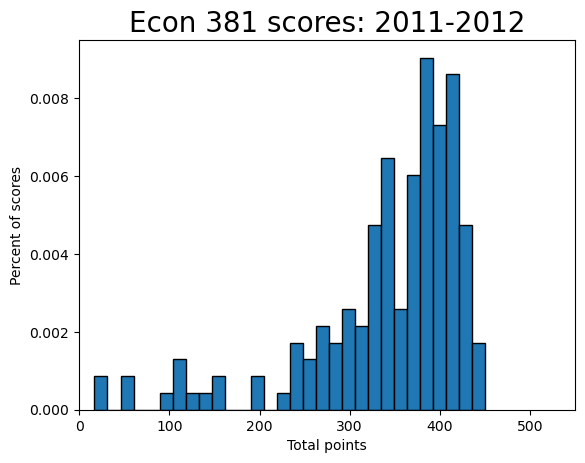

In [3]:
import matplotlib.pyplot as plt
# This next command is specifically for Jupyter Notebook
%matplotlib inline

num_bins = 30
count, bins, ignored = plt.hist(pts, num_bins, density=True,
                                edgecolor='k')
plt.title('Econ 381 scores: 2011-2012', fontsize=20)
plt.xlabel(r'Total points')
plt.ylabel(r'Percent of scores')
plt.xlim([0, 550])  # This gives the xmin and xmax to be plotted"
plt.show()

Now let's create a distribution around these data that we think fits it well.

In [5]:
# Define function that generates values of a normal pdf
def trunc_norm_pdf(xvals, mu, sigma, cut_lb, cut_ub):
    '''
    --------------------------------------------------------------------
    Generate pdf values from the normal pdf with mean mu and standard
    deviation sigma. If the cutoff is given, then the PDF values are
    inflated upward to reflect the zero probability on values above the
    cutoff. If there is no cutoff given, this function does the same
    thing as sp.stats.norm.pdf(x, loc=mu, scale=sigma).
    --------------------------------------------------------------------
    INPUTS:
    xvals  = (N,) vector, values of the normally distributed random
             variable
    mu     = scalar, mean of the normally distributed random variable
    sigma  = scalar > 0, standard deviation of the normally distributed
             random variable
    cut_lb = scalar or string, ='None' if no cutoff is given, otherwise
             is scalar lower bound value of distribution. Values below
             this value have zero probability
    cut_ub = scalar or string, ='None' if no cutoff is given, otherwise
             is scalar upper bound value of distribution. Values above
             this value have zero probability
    
    OTHER FUNCTIONS AND FILES CALLED BY THIS FUNCTION: None
    
    OBJECTS CREATED WITHIN FUNCTION:
    prob_notcut = scalar 
    pdf_vals = (N,) vector, normal PDF values for mu and sigma
               corresponding to xvals data
    
    FILES CREATED BY THIS FUNCTION: None
    
    RETURNS: pdf_vals
    --------------------------------------------------------------------
    '''
    if cut_ub == 'None' and cut_lb == 'None':
        prob_notcut = 1.0
    elif cut_ub == 'None' and cut_lb != 'None':
        prob_notcut = 1.0 - sts.norm.cdf(cut_lb, loc=mu, scale=sigma)
    elif cut_ub != 'None' and cut_lb == 'None':
        prob_notcut = sts.norm.cdf(cut_ub, loc=mu, scale=sigma)
    elif cut_ub != 'None' and cut_lb != 'None':
        prob_notcut = (sts.norm.cdf(cut_ub, loc=mu, scale=sigma) -
                       sts.norm.cdf(cut_lb, loc=mu, scale=sigma))
            
    pdf_vals    = ((1/(sigma * np.sqrt(2 * np.pi)) *
                    np.exp( - (xvals - mu)**2 / (2 * sigma**2))) /
                    prob_notcut)
    
    return pdf_vals

MEMEMEM 1.0


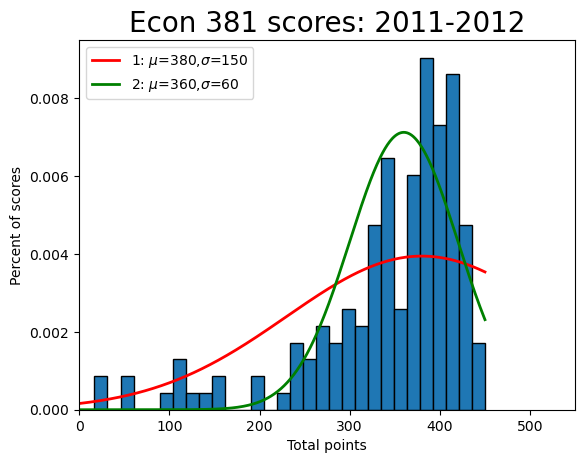

In [6]:
# Plot two different truncated normal distributions on top of the
# histogram of the data

# Plot histogram
num_bins = 30
count, bins, ignored = plt.hist(pts, num_bins, density=True,
                                edgecolor='k')
plt.title('Econ 381 scores: 2011-2012', fontsize=20)
plt.xlabel(r'Total points')
plt.ylabel(r'Percent of scores')
plt.xlim([0, 550])  # This gives the xmin and xmax to be plotted"
print('MEMEMEM', (count*(bins[1:]-bins[:-1])).sum())

# Plot smooth line with distribution 1
dist_pts = np.linspace(0, 450, 500)
mu_1 = 380
sig_1 = 150
plt.plot(dist_pts, trunc_norm_pdf(dist_pts, mu_1, sig_1, 0, 450),
         linewidth=2, color='r', label='1: $\mu$=380,$\sigma$=150')
plt.legend(loc='upper left')

# Plot smooth line with distribution 2
mu_2 = 360
sig_2 = 60
plt.plot(dist_pts, trunc_norm_pdf(dist_pts, mu_2, sig_2, 0, 450),
         linewidth=2, color='g', label='2: $\mu$=360,$\sigma$=60')
plt.legend(loc='upper left')
plt.show()

Which distribution will have the biggest log likelihood function? Why?

Let's compute the log likelihood function for this data for both of these distributions.

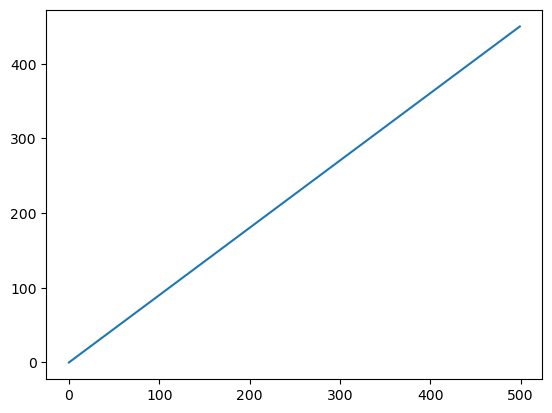

In [50]:
plt.plot(range(len(dist_pts)), dist_pts)
plt.show()

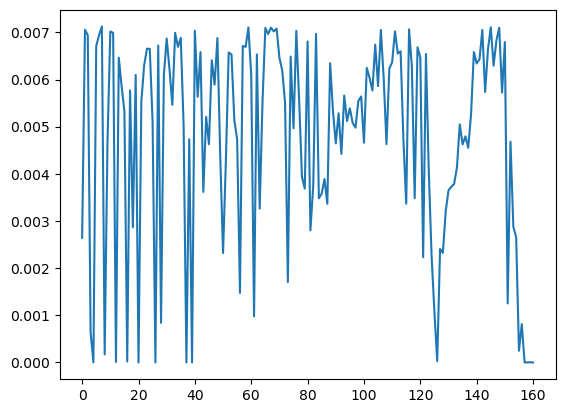

In [47]:
plt.plot(range(len(pts)), check3)
plt.show()

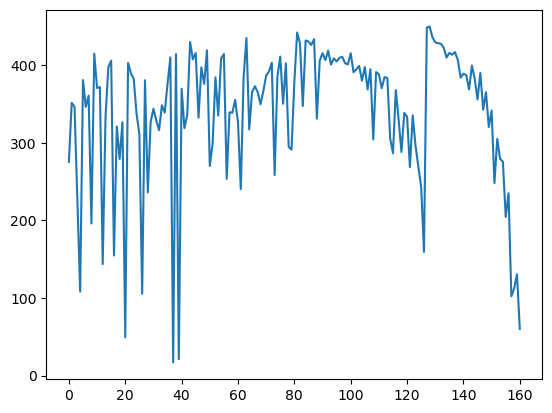

In [48]:
check1 = trunc_norm_pdf(dist_pts, mu_1, sig_1, 0, 450)
check2 = trunc_norm_pdf(dist_pts, mu_2, sig_2, 0, 450)
check3 = trunc_norm_pdf(pts, mu_2, sig_2, 0, 450)


plt.plot(range(len(pts)), pts)

plt.show()

In [11]:
# Define log likelihood function for the normal distribution
def log_lik_truncnorm(xvals, mu, sigma, cut_lb, cut_ub):
    '''
    --------------------------------------------------------------------
    Compute the log likelihood function for data xvals given normal
    distribution parameters mu and sigma.
    --------------------------------------------------------------------
    INPUTS:
    xvals  = (N,) vector, values of the normally distributed random
             variable
    mu     = scalar, mean of the normally distributed random variable
    sigma  = scalar > 0, standard deviation of the normally distributed
             random variable
    cutoff = scalar or string, ='None' if no cutoff is given, otherwise
             is scalar upper bound value of distribution. Values above
             this value have zero probability
    
    OTHER FUNCTIONS AND FILES CALLED BY THIS FUNCTION:
        trunc_norm_pdf()
    
    OBJECTS CREATED WITHIN FUNCTION:
    pdf_vals    = (N,) vector, normal PDF values for mu and sigma
                  corresponding to xvals data
    ln_pdf_vals = (N,) vector, natural logarithm of normal PDF values
                  for mu and sigma corresponding to xvals data
    log_lik_val = scalar, value of the log likelihood function
    
    FILES CREATED BY THIS FUNCTION: None
    
    RETURNS: log_lik_val
    --------------------------------------------------------------------
    '''
    pdf_vals = trunc_norm_pdf(xvals, mu, sigma, cut_lb, cut_ub)
    ln_pdf_vals = np.log(pdf_vals)
    log_lik_val = ln_pdf_vals.sum()
    
    return log_lik_val

print('Log-likelihood 1: ', log_lik_truncnorm(pts, mu_1, sig_1, 0, 450))
print('Log-likelihood 2: ', log_lik_truncnorm(pts, mu_2, sig_2, 0, 450))
print('Log-likelihood 3: ', log_lik_truncnorm(dist_pts, mu_2, sig_2, 0, 450))

Log-likelihood 1:  -924.3364498667136
Log-likelihood 2:  -978.3678854857621
Log-likelihood 3:  -4914.2667131662365


Why is the log likelihood value negative?

How do we estimate $\mu$ and $\sigma$ by maximum likelihood? What values of $\mu$ and $\sigma$ will maximize the likelihood function?
$$(\hat{\mu},\hat{\sigma})_{MLE} = (\mu, \sigma):\quad argmax_{\mu,\sigma}\:\mathcal{L}=\sum_{i=1}^N\ln\Bigl(f(x_i|\mu,\sigma)\Bigr)$$

## 3. How to set up a maximization (minimization) problem in Python
A minimizer is a function that chooses a single value or a vector of values to minimize the result of a scalar-valued function of that vector. Any maximization problem can be restated as a minimization problem. Because minimization problems are more numerically stable and well defined, most numerical optimizers are stated as minimizers. The [scipy.optimize](https://docs.scipy.org/doc/scipy-0.18.1/reference/optimize.html) library has many types of root-finders and minimizers. For our maximum likelihood estimation problems, we will use the [scipy.optimize.minimize()](https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize) function.

### 3.1. The criterion function
The first step is to write a function that takes two inputs and returns a scalar value.
1. The first input is either a scalar or a vector of values (the object `params` in the function `crit()` below). This object is the value or values being chosen to minimize the criterion function.
2. The second object is Python's variable length input objects `*args`, which is a tuple of variable length positional arguments. As you will see in the `minimize()` function, all the arguments must be passed into the criterion function in one tuple.
3. Lastly, you must make sure that the scalar criterion value that the function returns is the value of the problem stated as a minimization problem and not a maximization problem. In this case of maximum likelihood estimation, you want the negative of the log likelihood function.

In [8]:
def crit(params, *args):
    '''
    --------------------------------------------------------------------
    This function computes the negative of the log likelihood function
    given parameters and data. This is the minimization problem version
    of the maximum likelihood optimization problem
    --------------------------------------------------------------------
    INPUTS:
    params = (2,) vector, ([mu, sigma])
    mu     = scalar, mean of the normally distributed random variable
    sigma  = scalar > 0, standard deviation of the normally distributed
             random variable
    args   = length 2 tuple, (xvals, cutoff)
    xvals  = (N,) vector, values of the normally distributed random
             variable
    cutoff = scalar or string, ='None' if no cutoff is given, otherwise
             is scalar upper bound value of distribution. Values above
             this value have zero probability
    
    OTHER FUNCTIONS AND FILES CALLED BY THIS FUNCTION:
        log_lik_truncnorm()
    
    OBJECTS CREATED WITHIN FUNCTION:
    log_lik_val = scalar, value of the log likelihood function
    neg_log_lik_val = scalar, negative of log_lik_val
    
    FILES CREATED BY THIS FUNCTION: None
    
    RETURNS: neg_log_lik_val
    --------------------------------------------------------------------
    '''
    mu, sigma = params
    xvals, cut_lb, cut_ub = args
    log_lik_val = log_lik_truncnorm(xvals, mu, sigma, cut_lb, cut_ub)
    neg_log_lik_val = -log_lik_val
    
    return neg_log_lik_val

### 3.2. The minimize() function
The `minimize()` function is shorthand for `scipy.optimize.minimize()`. This function returns a dictionary of objects including the solution to the optimization problem and whether the problem actually solved. The `minimize` function has three mandatory arguments, plus a lot of options. You can experiment with the options on the [`minimize()` documentation page](https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize).
1. The first argument of the minimize function is the criterion function (`crit()` in this example) from which the `minimize()` function will test values of the parameters in searching for the minimum value.
2. The second argument is an initial guess for the values of the parameters that minimize the criterion function `crit()`.
3. The third argument is the tuple of all the objects needed to solve the criterion function in `crit()`.

In [69]:
import scipy.optimize as opt

mu_init = 385  # mu_2
sig_init = 120  # sig_2
params_init = np.array([mu_init, sig_init])
mle_args = (pts, 0, 700.0)
results_uncstr = opt.minimize(crit, params_init, args=(mle_args))
mu_MLE, sig_MLE = results_uncstr.x
print('mu_MLE=', mu_MLE, ' sig_MLE=', sig_MLE)

mu_MLE= 341.8984085008556  sig_MLE= 88.53547305536614


In [70]:
results_uncstr

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 950.1555858012566
        x: [ 3.419e+02  8.854e+01]
      nit: 7
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 4.796e+01  1.255e-02]
            [ 1.255e-02  2.469e+01]]
     nfev: 39
     njev: 13

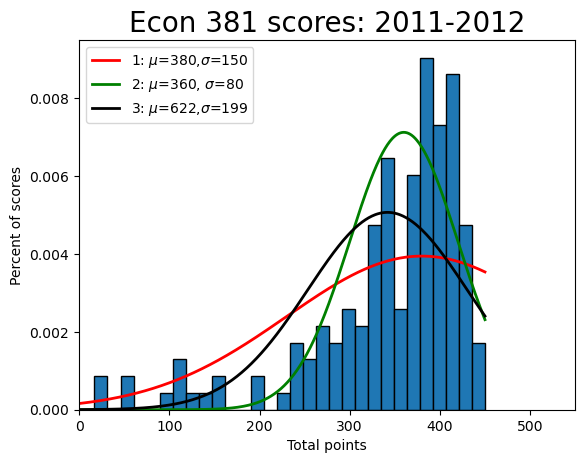

In [71]:
# Plot the histogram of the data
count, bins, ignored = plt.hist(pts, num_bins, density=True,
                                edgecolor='k')
plt.title('Econ 381 scores: 2011-2012', fontsize=20)
plt.xlabel(r'Total points')
plt.ylabel(r'Percent of scores')
plt.xlim([0, 550])  # This gives the xmin and xmax to be plotted"

# Plot the two test distributions from before
plt.plot(dist_pts, trunc_norm_pdf(dist_pts, mu_1, sig_1, 0, 450),
         linewidth=2, color='r', label='1: $\mu$=380,$\sigma$=150')
plt.legend(loc='upper left')

plt.plot(dist_pts, trunc_norm_pdf(dist_pts, mu_2, sig_2, 0, 450),
         linewidth=2, color='g', label='2: $\mu$=360, $\sigma$=80')
plt.legend(loc='upper left')

# Plot the MLE estimated distribution
plt.plot(dist_pts, trunc_norm_pdf(dist_pts, mu_MLE, sig_MLE, 0, 450),
         linewidth=2, color='k', label='3: $\mu$=622,$\sigma$=199')
plt.legend(loc='upper left')
plt.show()
plt.savefig('images/MLEplots.png')

In [72]:
print('Log-likelihood 1: ', log_lik_truncnorm(pts, mu_1, sig_1, 0, 450))
print('Log-likelihood 2: ', log_lik_truncnorm(pts, mu_2, sig_2, 0, 450))
print('MLE log-likelihood 3: ', log_lik_truncnorm(pts, mu_MLE, sig_MLE, 0, 450))

Log-likelihood 1:  -924.3364498667136
Log-likelihood 2:  -978.3678854857621
MLE log-likelihood 3:  -931.2078507710632


Let's see if this likelihood function is well behaved by looking at a grid over possible values of $\mu$ and $\sigma$ for the given data.

/var/folders/k6/44yk55hj6cx3_32bfydgxhfm0000gn/T/ipykernel_33365/3274765919.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = matplotlib.cm.get_cmap('summer')


<Figure size 640x480 with 0 Axes>

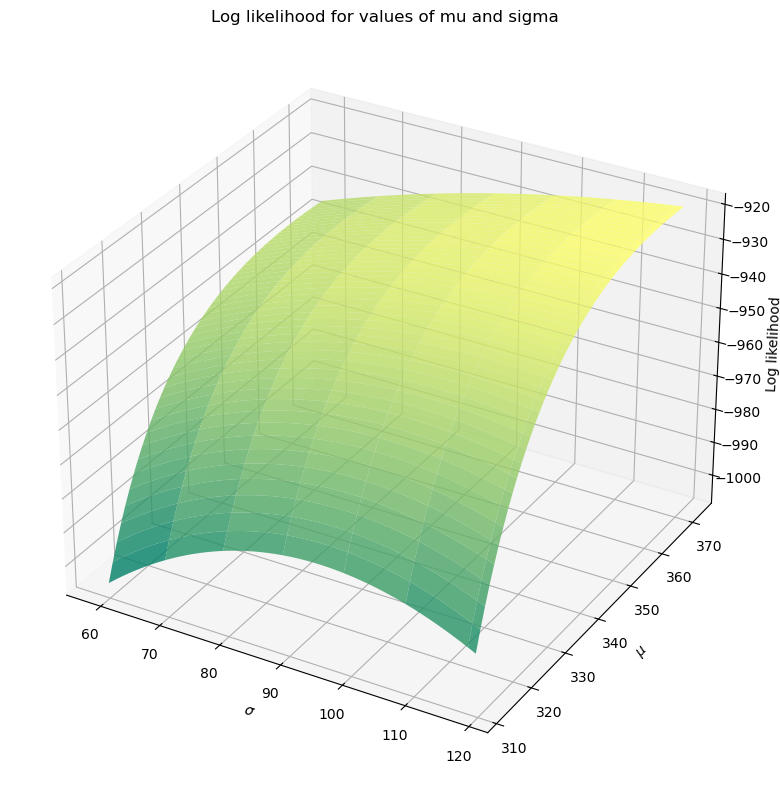

In [73]:
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Get colormap
cmap1 = matplotlib.cm.get_cmap('summer')

# Create parameter grids
mu_vals = np.linspace(mu_MLE - 30, mu_MLE + 30, 50)
sig_vals = np.linspace(sig_MLE - 30, sig_MLE + 30, 50)

# Calculate log-likelihood values
lnlik_vals = np.zeros((50, 50))
for mu_ind in range(50):
    for sig_ind in range(50):
        lnlik_vals[mu_ind, sig_ind] = \
            log_lik_truncnorm(pts, mu_vals[mu_ind],
                              sig_vals[sig_ind], 0, 450)

# Create meshgrid
mu_mesh, sig_mesh = np.meshgrid(mu_vals, sig_vals)

# Create 3D plot - FIXED VERSION
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')  # Use add_subplot instead of gca

# Create surface plot
ax.plot_surface(sig_mesh, mu_mesh, lnlik_vals, rstride=8,
                cstride=1, cmap=cmap1, alpha=0.8)

# Set labels and title
ax.set_title('Log likelihood for values of mu and sigma')
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$\mu$')
ax.set_zlabel(r'Log likelihood')

plt.tight_layout()
plt.show()

### 3.3. Constrained minimization using the minimize() function
The `minimize()` function has many methods that can be used to find the parameter values that minimize some criterion function. These methods are called using the `method='MethodName'` optional input argument to the minimize function. Three of those methods allow for constrained minimization by providing upper and lower bounds for the parameters being chosen. These three methods are `'L-BFGS-B'`, `'TNC'`, and `'SLSQP'`.

Suppose you were trying to estimate $\mu$ and $\sigma$ of a truncated normal distribution as is the case above. The value of $\mu$ need not be constrained. However, the value of $\sigma$ must be strictly positive. You could include these bounds in a constrained minimization by using the following code.

In [76]:
params_init = np.array([400, 80])
results_cstr = opt.minimize(crit, params_init, args=(mle_args), method='L-BFGS-B',
                            bounds=((350, 420), (1e-10, None)))
results_cstr.hess_inv.todense()

array([[55.72088939,  5.12631454],
       [ 5.12631454, 25.22596859]])

Note that you must set the lower bound of $\sigma$ equal to some small positive number close to zero. You cannot set it to zero itself because the bounds are inclusive. That is, the minimizer might try a value of $\sigma=0$ is the lower bound includes zero.

## 4. The variance-covariance matrix of ML estimates
Davidson and MacKinnon (2004, Sec. 10.4) have a great discussion four different estimators for the variance-covariance matrix of the maximum likelihood estimates. That is, we want to know what is the variance or uncertainty of our estimates for $\mu$ and $\sigma$, and how are those two estimates correlated. The four most common estimators for the VCV matrix of a maximum likelihood estimate are:
1. Empirical Hessian estimator (H)
2. Information matrix estimator (I)
3. Outer-product-of-the-gradient estimator (OPG)
4. Sandwich estimator (S)

All of these estimators of the VCV matrix intuitively measure how flat the likelihood function is at the estimated parameter values in the dimension of each estimated parameter. The Hessian is a matrix of second derivatives of the log likelihood function with respect to the parameters being chosen. The Hessian matrix therefore captures information about how the slope of the log likelihood function is changing in each direction.The empirical Hessian estimator is the most commonly used. One really nice property of Python's `minimize()` function is that one of the result objects is the inverse Hessian.

$$ \hat{VAR}_H(\hat{\theta}) =-H^{-1}(\hat{\theta}) $$

In [77]:
results_uncstr
vcv_mle = results_uncstr.hess_inv

stderr_mu_mle = np.sqrt(vcv_mle[0,0])
stderr_sig_mle = np.sqrt(vcv_mle[1,1])
print('VCV(MLE) = ', vcv_mle)
print('Standard error for mu estimate = ', stderr_mu_mle)
print('Standard error for sigma estimate = ', stderr_sig_mle)

VCV(MLE) =  [[4.79573064e+01 1.25544696e-02]
 [1.25544696e-02 2.46856810e+01]]
Standard error for mu estimate =  6.92512140281705
Standard error for sigma estimate =  4.968468676724123


In [78]:
print('mu percent', stderr_mu_mle/mu_MLE)
print('sig percent', stderr_sig_mle/sig_MLE)

mu percent 0.020254909735269267
sig percent 0.05611839531954682


## 5. Hypothesis testing
Can we reject the hypothesis that $\mu=400$ and $\sigma=70$ with 95% confidence? How do you answer that question? What does the figure tell us about this answer? In this section, we will discuss four ways to perform hypothesis testing.
1. Two standard errors (back of the envelope, approximation)
2. Likelihood ratio test
3. Wald test
4. Lagrange multiplier test

Davidson and MacKinnon (2004, Sec. 10.5) have a more detailed discussion of methods 2, 3, and 4.

### 5.1. Back of the envelope, two standard errors (assuming normality)
A really quick approach to hypothesis testing is to see if your hypothesized values are within two standard errors of the estimated values. This approach is not completely correct because estimates in the log likelihood function are not symmetrically distributed. But it is at least a first approximation. 

In [79]:
lb_mu_95pctci = mu_MLE - 2 * stderr_mu_mle
print('mu_2=', mu_2, ', lower bound 95% conf. int.=', lb_mu_95pctci)

lb_sig_95pctci = sig_MLE - 2 * stderr_sig_mle
print('sig_2=', sig_2, ', lower bound 95% conf. int.=', lb_sig_95pctci)

mu_2= 360 , lower bound 95% conf. int.= 328.04816569522154
sig_2= 60 , lower bound 95% conf. int.= 78.5985357019179


### 5.2. Likelihood ratio test
The likelihood ratio test is the simplest and, therefore, the most common of the three more precise methods (2, 3, and 4). Let your maximum likelihood estimation have $p$ parameters (the vector $\theta$ has $p$ elements), let $\hat{\theta}_{MLE}$ be the maximum likelihood estimate, and let $\tilde{\theta}$ be your hypothesized values of the parameters. The likelihood ratio test statistic is the following.

$$ LR(\tilde{\theta}|\hat{\theta}_{MLE}) = 2\Bigl(\ln\ell(\hat{\theta}_{MLE}) - \ln\ell(\tilde{\theta})\Bigr) \sim \chi^2(p) $$

Note that this is a joint test of the likelihood of $H_0: \mu_0, \sigma_0$. The value of the $\chi^2(p)$ has the following interpretation. The area under the $\chi^2(p)$ pdf from $LR$ and above is the significance level or $p$-value. It represents the probability that the null hypothesis $\tilde{\theta}$ is true given the MLE estimate $\hat{\theta}_{MLE}$. More precisely, it represents the probability of null hypotheses with LR test statistics greater than or equal to (worse) the LR statistic from the null hypothese $\tilde{\theta}$. When this $p$-value is small, it it highly unlikely that the null hypothesis is true. You can calculate the $\chi^2(p)$ significance level by taking one minus the cdf of $\chi^2(p)$ at the $LR$ value.

In [80]:
mu_new, sig_new = np.array([420, 130])
print(mu_new, sig_new)
print(mu_MLE, sig_MLE)
log_lik_h0 = log_lik_truncnorm(pts, mu_new, sig_new, 0, 450)
print('hypothesis value log likelihood', log_lik_h0)
log_lik_mle = log_lik_truncnorm(pts, mu_MLE, sig_MLE, 0, 450)
print('MLE log likelihood', log_lik_mle)
LR_val = 2 * (log_lik_mle - log_lik_h0)
print('likelihood ratio value', LR_val)
pval_h0 = 1.0 - sts.chi2.cdf(LR_val, 2)
print('chi squared of H0 with 2 degrees of freedom p-value = ', pval_h0)

420 130
341.8984085008556 88.53547305536614
hypothesis value log likelihood -913.1817396241
MLE log likelihood -931.2078507710632
likelihood ratio value -36.052222293926434
chi squared of H0 with 2 degrees of freedom p-value =  1.0


In [82]:
sts.chi2.cdf(LR_val, 2)

np.float64(0.0)

In [81]:

if pval_h0 < 0.05:
    print("Reject H₀: Truncation is statistically significant")
else:
    print("Fail to reject H₀: Regular normal distribution is adequate")


Fail to reject H₀: Regular normal distribution is adequate


## 6. Linear regression with MLE
Although linear regression is most often performed using the ordinary least squares (OLS) estimator, which is a particular type of generalized method of moments (GMM) estimator, this can also be done using MLE. A simple regression specification in which the dependent variable $y_i$ is a linear function of two independent variables $x_{1,i}$ and $x_{2,i}$ is the following:

$$ y_i = \beta_0 + \beta_1 x_{1,i} + \beta_2 x_{2,i} + \varepsilon_i \quad\text{where}\quad \varepsilon_i\sim N\left(0,\sigma^2\right) $$

If we solve this regression equation for the error term $\varepsilon_i$, we can start to see how we might estimate the parameters of the model by maximum likelihood.

$$ \varepsilon_i = y_i - \beta_0 - \beta_1 x_{1,i} - \beta_2 x_{2,i} \sim N\left(0,\sigma^2\right) $$

The parameters of the regression model are $(\beta_0, \beta_1, \beta_2, \sigma)$. Given some data $(y_i, x_{1,i}, x_{2,i})$ and given some parameter values $(\beta_0, \beta_1, \beta_2, \sigma)$, we could plot a histogram of the distribution of those error terms. And we could compare that empirical histogram to the assumed histogram of the distribution of the errors $N(0,\sigma^2)$. ML estimation of this regression equation is to choose the paramters $(\beta_0, \beta_1, \beta_2, \sigma)$ to make that empirical distribution of errors $\varepsilon_i$ most closely match the assumed distribution of errors $N(0,\sigma^2)$.

/var/folders/k6/44yk55hj6cx3_32bfydgxhfm0000gn/T/ipykernel_38505/198766098.py:40: RuntimeWarning: invalid value encountered in log
  nll = n * np.log(sigma) + 0.5 * np.sum(residuals**2) / (sigma**2)


=== Maximum Likelihood Estimation Results ===
True parameters:     β₀=2.500, β₁=1.800, β₂=-0.700, σ=1.200
MLE estimates:       β₀=2.495, β₁=1.806, β₂=-0.702, σ=1.189
OLS estimates:       β₀=2.495, β₁=1.806, β₂=-0.702, σ=1.189
Optimization success: True


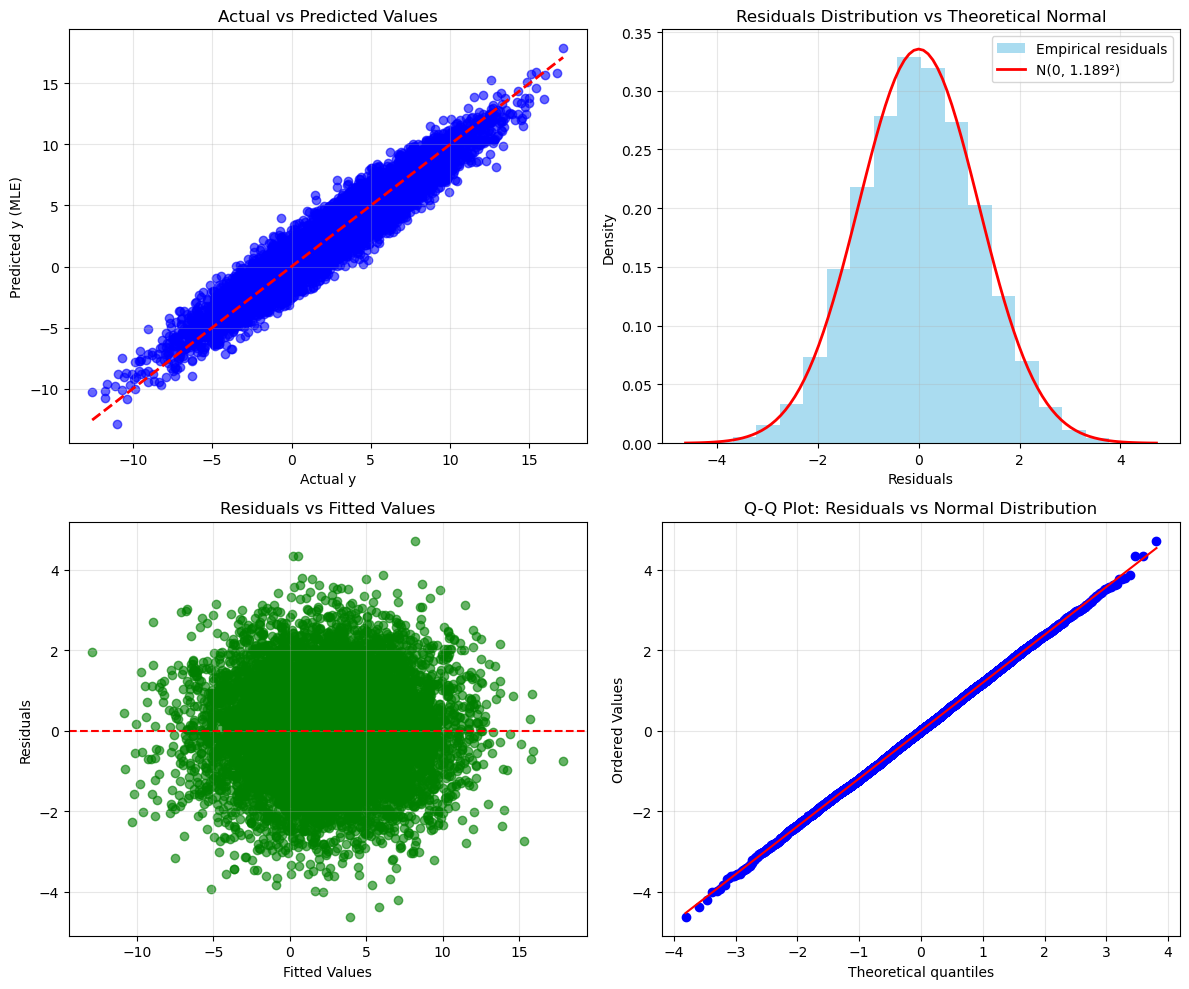


Model Performance:
R-squared: 0.9120
Log-likelihood: -6731.8556
AIC: 13471.7112


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n = 10000  # number of observations
true_beta0 = 2.5   # true intercept
true_beta1 = 1.8   # true coefficient for x1
true_beta2 = -0.7  # true coefficient for x2
true_sigma = 1.2   # true error standard deviation

# Generate independent variables
x1 = np.random.normal(0, 2, n)
x2 = np.random.uniform(-3, 3, n)

# Generate error terms
epsilon = np.random.normal(0, true_sigma, n)

# Generate dependent variable
y = true_beta0 + true_beta1 * x1 + true_beta2 * x2 + epsilon

# Define the negative log-likelihood function
def neg_log_likelihood(params, y, x1, x2):
    beta0, beta1, beta2, sigma = params
    
    # Calculate predicted values
    y_pred = beta0 + beta1 * x1 + beta2 * x2
    
    # Calculate residuals
    residuals = y - y_pred
    
    # Calculate negative log-likelihood
    # For normal distribution: -log(L) = n/2 * log(2π) + n*log(σ) + Σ(residuals²)/(2σ²)
    n = len(y)
    nll = n * np.log(sigma) + 0.5 * np.sum(residuals**2) / (sigma**2)
    
    return nll

# Initial parameter guesses
initial_params = [0, 0, 0, 1]  # [beta0, beta1, beta2, sigma]

# Constraints: sigma must be positive
constraints = {'type': 'ineq', 'fun': lambda x: x[3]}  # x[3] > 0

# Perform MLE optimization
result = minimize(neg_log_likelihood, initial_params, 
                 args=(y, x1, x2), method='SLSQP', constraints=constraints)

# Extract estimated parameters
beta0_mle, beta1_mle, beta2_mle, sigma_mle = result.x

# Compare with OLS (using normal equations for comparison)
X = np.column_stack([np.ones(n), x1, x2])  # Design matrix with intercept
beta_ols = np.linalg.inv(X.T @ X) @ X.T @ y
residuals_ols = y - X @ beta_ols
sigma_ols = np.sqrt(np.sum(residuals_ols**2) / (n - 3))

# Display results
print("=== Maximum Likelihood Estimation Results ===")
print(f"True parameters:     β₀={true_beta0:.3f}, β₁={true_beta1:.3f}, β₂={true_beta2:.3f}, σ={true_sigma:.3f}")
print(f"MLE estimates:       β₀={beta0_mle:.3f}, β₁={beta1_mle:.3f}, β₂={beta2_mle:.3f}, σ={sigma_mle:.3f}")
print(f"OLS estimates:       β₀={beta_ols[0]:.3f}, β₁={beta_ols[1]:.3f}, β₂={beta_ols[2]:.3f}, σ={sigma_ols:.3f}")
print(f"Optimization success: {result.success}")

# Calculate residuals for MLE
y_pred_mle = beta0_mle + beta1_mle * x1 + beta2_mle * x2
residuals_mle = y - y_pred_mle

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Actual vs Predicted values
ax1.scatter(y, y_pred_mle, alpha=0.6, color='blue')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel('Actual y')
ax1.set_ylabel('Predicted y (MLE)')
ax1.set_title('Actual vs Predicted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals histogram vs theoretical normal distribution
ax2.hist(residuals_mle, bins=20, density=True, alpha=0.7, color='skyblue', 
         label='Empirical residuals')
x_norm = np.linspace(residuals_mle.min(), residuals_mle.max(), 100)
ax2.plot(x_norm, norm.pdf(x_norm, 0, sigma_mle), 'r-', lw=2, 
         label=f'N(0, {sigma_mle:.3f}²)')
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Density')
ax2.set_title('Residuals Distribution vs Theoretical Normal')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Residuals vs fitted values
ax3.scatter(y_pred_mle, residuals_mle, alpha=0.6, color='green')
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals vs Fitted Values')
ax3.grid(True, alpha=0.3)

# Plot 4: Q-Q plot for normality check
from scipy import stats
stats.probplot(residuals_mle, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot: Residuals vs Normal Distribution')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate R-squared
ss_res = np.sum(residuals_mle**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nModel Performance:")
print(f"R-squared: {r_squared:.4f}")
print(f"Log-likelihood: {-result.fun:.4f}")
print(f"AIC: {2 * len(result.x) + 2 * result.fun:.4f}")

## 7. Generalized beta family of distributions
For exercises in this section, you will need to know the functional forms of four continuous univariate probability density functions (PDF's), each of which are part of the generalized beta family of distributions. The figure below is the generalized beta family of distributions [taken from McDonald and Xu (1995, Fig. 2)].

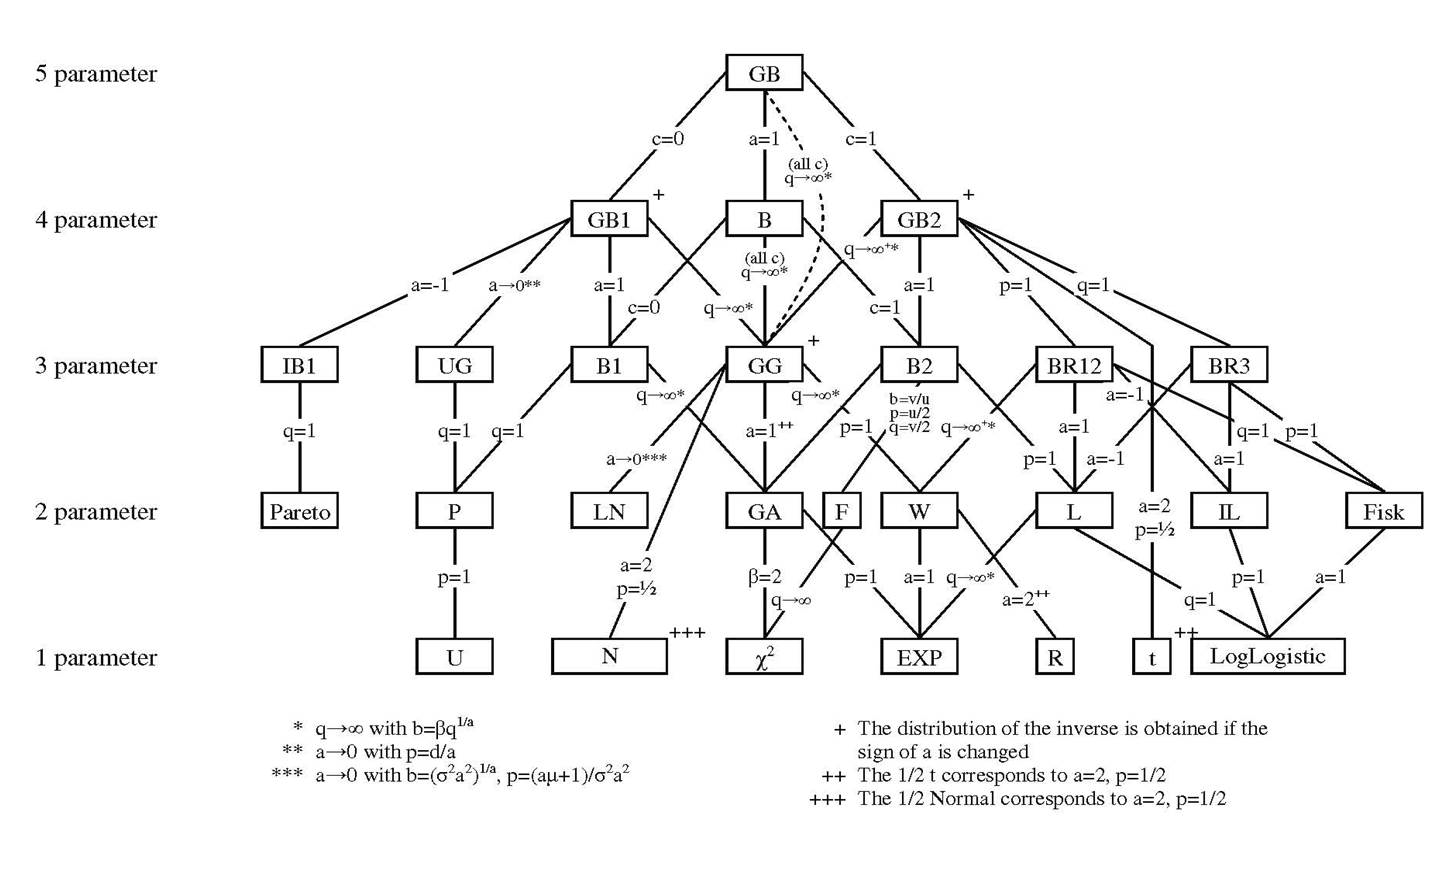

In [5]:
from IPython.display import Image

# Download and save the data file GBtree.png
url = ('https://raw.githubusercontent.com/rickecon/Notebooks/' +
       'master/MLE/images/GBtree.png')
image_file = requests.get(url, allow_redirects=True)
open('images/GBtree.png', 'wb').write(image_file.content)
Image("images/GBtree.png")

The lognormal distribution (LN) is the distribution of the exponential of a normally distributed variable with mean $\mu$ and standard deviation $\sigma$. If the variable $x_i$ is lognormally distributed $x_i\sim LN(\mu,\sigma)$, then the log of $x_i$ is normally distributed $\ln(x_i)\sim N(\mu,\sigma)$. The PDF of the lognormal distribution is the following.

$$ \text{(LN):}\quad f(x;\mu,\sigma) = \frac{1}{x\sigma\sqrt{2\pi}}e^{-\frac{[\ln(x)-\mu]^2}{2\sigma^2}},\quad x\in(0,\infty), \:\mu\in(-\infty,\infty),\: \sigma>0 $$

Note that the lognormal distribution has a support that is strictly positive. This is one reason why it is commonly used to approximate income distributions. A household's total income is rarely negative. The lognormal distribution also has a lot of the nice properties of the normal distribution.

Another two-parameter distribution with strictly positive support is the gamma (GA) distribution. The pdf of the gamma distribution is the following.

$$ \text{(GA):}\quad f(x;\alpha,\beta) = \frac{1}{\beta^\alpha \Gamma(\alpha)}x^{\alpha-1}e^{-\frac{x}{\beta}},\quad x\in[0,\infty), \:\alpha,\beta>0 $$
$$ \text{where}\quad \Gamma(z)\equiv\int_0^\infty t^{z-1}e^{-t}dt $$

The gamma function $\Gamma(\cdot)$ within the gamma (GA) distribution is a common function that has a preprogrammed function in most programming languages.

The lognormal (LN) and gamma (GA) distributions are both two-parameter distributions and are both special cases of the three-parameter generalized gamma (GG) distribution. The pdf of the generalized gamma distribution is the following.

$$ \text{(GG):}\quad f(x;\alpha,\beta,m) = \frac{m}{\beta^\alpha \Gamma\left(\frac{\alpha}{m}\right)}x^{\alpha-1}e^{-\left(\frac{x}{\beta}\right)^m},\quad x\in[0,\infty), \:\alpha,\beta,m>0 $$
$$ \text{where}\quad \Gamma(z)\equiv\int_0^\infty t^{z-1}e^{-t}dt $$

The relationship between the generalized gamma (GG) distribution and the gamma (GA) distribution is straightforward. The GA distribution equals the GG distribution at $m=1$.

$$ GA(\alpha,\beta) = GG(\alpha,\beta,m=1) $$

The relationship between the generalized gamma (GG) distribution and the lognormal (LN) distribution is less straightforward. The LN distribution equals the GG distribution as $\alpha$ goes to zero, $\beta = (\alpha\sigma)^{\frac{2}{\alpha}}$, and $m = \frac{\alpha\mu+1}{\alpha^2\sigma^2}$. See McDonald, et al (2013) for derivation.

$$ LN(\mu,\sigma) = \lim_{\alpha\rightarrow 0}GG\left(\alpha,\beta=(\alpha\sigma)^{\frac{2}{\alpha}},m=\frac{\alpha\mu+1}{\alpha^2\sigma^2}\right) $$

The last distribution we describe is the generalized beta 2 (GB2) distribution. Like the GG, GA, and LN distributions, it also has a strictly positive support. The PDF of the generalized beta 2 distribution is the following.

$$ \text{(GB2):}\quad f(x;a,b,p,q) = \frac{a x^{ap-1}}{b^{ap}B(p,q)\left(1 + \left(\frac{x}{b}\right)^a\right)^{p+q}},\quad x\in[0,\infty), \:a,b,p,q>0 $$
$$ \quad\text{where}\quad B(v,w)\equiv\int_0^1 t^{v-1}(1-t)^{w-1}dt $$

The beta function $B(\cdot,\cdot)$ within the GB2 distribution is a common function that has a preprogrammed function in most programming languages. The three-parameter generalized gamma (GG) distribution is a nested case of the four-parameter generalized beta 2 (GB2) distribution as $q$ goes to $\infty$ and for $a=m$, $b=q^{1/m}\beta$, and $p=\frac{\alpha}{m}$. See McDonald (1984, p. 662) for a derivation.

$$ GG(\alpha,\beta,m) = \lim_{q\rightarrow\infty}GB2\left(a=m,b=q^{1/m}\beta,p=\frac{\alpha}{m},q\right) $$

The statistical family tree figure above shows the all the relationships between the various PDF's in the generalized beta family of distributions.

## 8. References
* Brock, William A. and Leonard J. Mirman, "Optimal Economic Growth and Uncertainty: The Discounted Case," *Journal of Economic Theory*, 4:3, pp. 479-513 (June 1972).
* Davidson, Russell and James G. MacKinnon, *Econometric Theory and Methods*, Oxford University Press (2004).
* McDonald, James B., "Some Generalized Functions for the Size Distribution of Income," *Econometrica* 52:3, pp. 647-665 (May 1984).
* McDonald, James B. and Yexiao Xu, "A Generalization of the Beta Distribution with Applications," *Journal of Econometrics*, 66:1-2, pp. 133-152 (March-April 1995).
* McDonald, James B., Jeff Sorensen, and Patrick A. Turley, "Skewness and Kurtosis Properties of Income Distribution Models," *Review of Income and Wealth*, 59:2, pp. 360-374 (June 2013).

# Macro Series maximum likelihood 

In [6]:
import os
import numpy as np
from pathlib import Path
import pandas as pd

# Check your current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

Current working directory: /Users/dinglebg/Documents/GitHub/StructEst_W20/Notebooks/MLE


In [1]:
import pandas as pd

# Load the data without headers
Macro = pd.read_csv('../../ProblemSets/PS2/MacroSeries.txt', header=None)

# Method 1: Assign column names directly
Macro.columns = ['c', 'k', 'w', 'r']

# Now you can access each series by name
c = Macro['c']  # consumption
k = Macro['k']  # capital
w = Macro['w']  # wages
r = Macro['r']  # interest rate

# Method 2: Alternative - assign column names during loading
Macro = pd.read_csv('../../ProblemSets/PS2/MacroSeries.txt', 
                   header=None, 
                   names=['c', 'k', 'w', 'r'])

# Method 3: Access columns by position and assign to variables
c = Macro.iloc[:, 0]  # first column
k = Macro.iloc[:, 1]  # second column  
w = Macro.iloc[:, 2]  # third column
r = Macro.iloc[:, 3]  # fourth column

# Method 4: Unpack all columns at once
c, k, w, r = Macro.iloc[:, 0], Macro.iloc[:, 1], Macro.iloc[:, 2], Macro.iloc[:, 3]

# Or more concisely:
c, k, w, r = [Macro.iloc[:, i] for i in range(4)]

# Verify your data
print("Data loaded successfully!")
print(f"Data shape: {Macro.shape}")
print(f"Column names: {Macro.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(Macro.head())

print(f"\nSummary statistics:")
print(Macro.describe())

Data loaded successfully!
Data shape: (100, 4)
Column names: ['c', 'k', 'w', 'r']

First 5 rows:
              c             k             w         r
0  1.067109e+07  8.040697e+06  1.059438e+07  0.954120
1  1.169487e+07  7.595072e+06  1.161079e+07  1.107009
2  9.292394e+06  8.323735e+06  9.225588e+06  0.802596
3  7.913165e+06  6.613792e+06  7.856274e+06  0.860176
4  8.140994e+06  5.632136e+06  8.082466e+06  1.039183

Summary statistics:
                  c             k             w           r
count  1.000000e+02  1.000000e+02  1.000000e+02  100.000000
mean   1.052085e+07  7.472545e+06  1.044521e+07    1.016947
std    2.387348e+06  1.686713e+06  2.370184e+06    0.101594
min    7.198780e+06  5.123678e+06  7.147026e+06    0.762142
25%    8.899324e+06  6.334027e+06  8.835344e+06    0.947913
50%    1.002475e+07  7.135045e+06  9.952684e+06    1.021391
75%    1.169416e+07  8.299804e+06  1.161009e+07    1.077150
max    1.856368e+07  1.321256e+07  1.843022e+07    1.333941


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd

β = 0.99

# 1. Get z
def back_out_z(alpha, w, k):
    w = np.asarray(w, dtype=float)
    k = np.asarray(k, dtype=float)
    return np.log(w / ((1 - alpha) * k**alpha))

## 1. Get z
#def back_out_z(α, w, k):
#
#    """Back out the z_t series given α and data (w_t, k_t)."""
#    z = np.log(w / ((1 - α) * k**α))
#    
#    return z
#
# Now we try to get the loglikelihood through z
# 2. LOG-LIKELIHOOD
#    From eq (5): z_t = ρ*z_{t-1} + (1-ρ)*μ + ε_t
#    => ε_t = z_t - ρ*z_{t-1} - (1-ρ)*μ  ~  N(0, σ²)
#
#    Assumption: z_0 = 0, so z_1 is the following process z_t = ρ*z_{t-1} + (1-ρ)*μ +ϵ_t
#    We condition on z_1, so the likelihood runs from t=2,...,T.

def n_log_likelihood(params, wt, kt):
    α, ρ, μ, σ = params
    z = back_out_z(α, wt, kt)   # ← pass wt, kt, not globals w, k
    z_curr = z[1:]
    z_prev = z[:-1]
    ε = z_curr - ρ * z_prev - (1 - ρ) * μ
    n = len(ε)
    nll = n * np.log(σ) + 0.5 * np.sum(ε**2) / (σ**2)
    return nll

# ─────────────────────────────────────────
# 3. OPTIMIZATION
# ─────────────────────────────────────────
# Initial guess for (α, ρ, μ, σ)
params0 = [0.5, 0.5, 1.0, 0.5]

result = minimize(
    n_log_likelihood,
    params0,
    args=(w, k),
    method="L-BFGS-B",          # gradient-based, handles box constraints
    bounds=[(1e-6, 1-1e-6),     # α ∈ (0,1)
            (-1+1e-6, 1-1e-6),  # ρ ∈ (-1,1)
            (1e-6, None),        # μ > 0
            (1e-6, None)],       # σ > 0
    options={"ftol": 1e-12, "gtol": 1e-8, "maxiter": 10_000}
)

# ─────────────────────────────────────────
# 4. RESULTS & VARIANCE-COVARIANCE MATRIX
# ─────────────────────────────────────────
alpha_hat, rho_hat, mu_hat, sigma_hat = result.x
print("=== MLE Estimates (Part a) ===")
print(f"  α̂  = {alpha_hat:.6f}")
print(f"  ρ̂  = {rho_hat:.6f}")
print(f"  μ̂  = {mu_hat:.6f}")
print(f"  σ̂  = {sigma_hat:.6f}")

=== MLE Estimates (Part a) ===
  α̂  = 0.251069
  ρ̂  = 0.999999
  μ̂  = 1.101757
  σ̂  = 0.097313


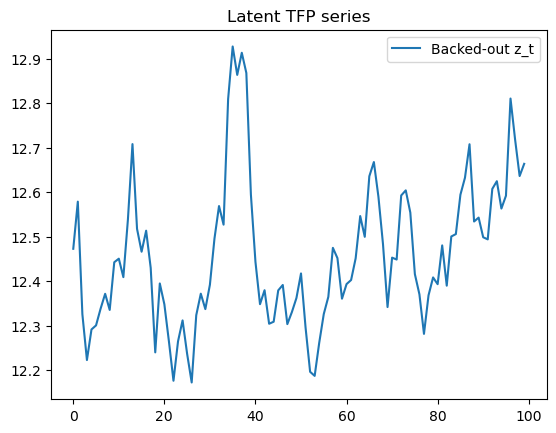

In [3]:
z = back_out_z(alpha_hat, w, k)
plt.plot(z, label='Backed-out z_t')
plt.title('Latent TFP series')
plt.legend()

In [4]:
mu_hat

np.float64(1.101757233517745)

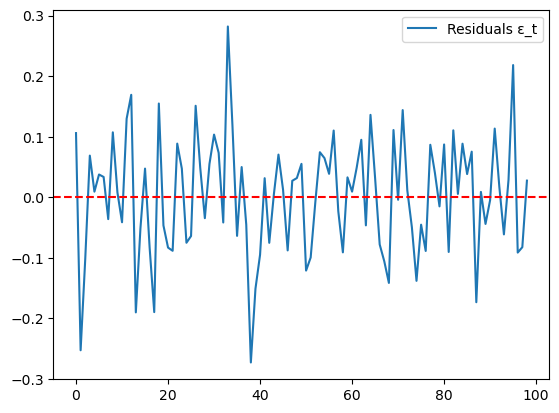

In [5]:
z_prev = np.concatenate([[mu_hat], z[:-1]])   # include z_0 = μ
eps = z[1:] - rho_hat * z_prev[1:] - (1 - rho_hat) * mu_hat

# Should be white noise around zero
plt.plot(eps, label='Residuals ε_t')
plt.axhline(0, color='r', linestyle='--')
plt.legend()

Text(0.5, 1.0, 'Q-Q plot of residuals')

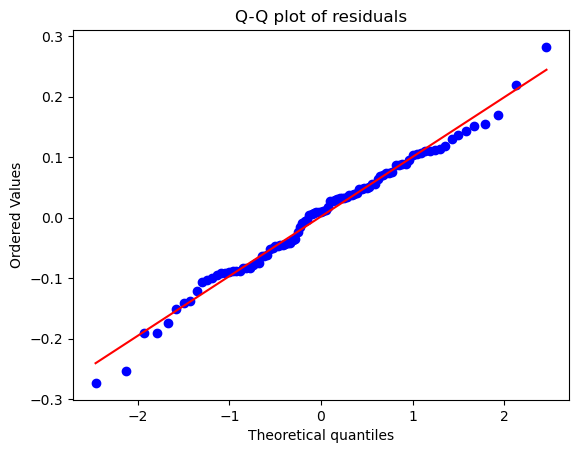

In [6]:
from scipy.stats import probplot
probplot(eps, dist="norm", plot=plt)
plt.title('Q-Q plot of residuals')


In [7]:
rho_hat

np.float64(0.999999)

In [8]:
mu_hat

np.float64(1.101757233517745)

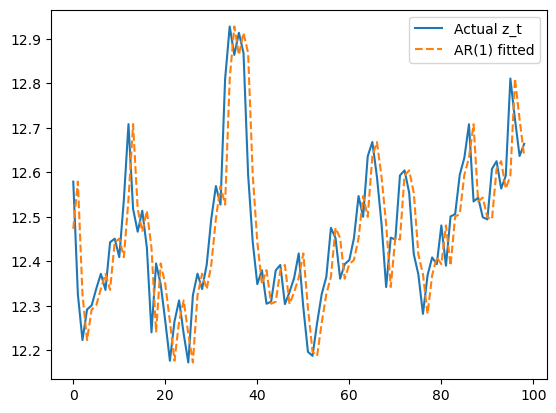

In [9]:
# Fitted values of z_t
z_fitted = rho_hat * z_prev + (1 - rho_hat) * mu_hat 

plt.plot(z[1:], label='Actual z_t')
plt.plot(z_fitted[1:], label='AR(1) fitted', linestyle='--')
plt.legend()

In [74]:


#T  = len(ct)      # number of periods (100)

# Known parameter
BETA = 0.99

# ─────────────────────────────────────────
# 1. RECOVER z_t FROM DATA
#    From eq (3): w_t = (1-α) * e^z_t * k_t^α
#    => e^z_t = w_t / ((1-α) * k_t^α)
#    => z_t   = log(w_t / ((1-α) * k_t^α))
# ─────────────────────────────────────────
def get_zt(alpha, w, k):
    w = np.asarray(w, dtype=float)
    k = np.asarray(k, dtype=float)
    return np.log(w / ((1 - alpha) * k**alpha))

def get_zt(alpha, r, k):
    r = np.asarray(r, dtype=float)
    k = np.asarray(k, dtype=float)
    return np.log(r / (alpha * k**(alpha-1)))
# ─────────────────────────────────────────
# 2. LOG-LIKELIHOOD
#    From eq (5): z_t = ρ*z_{t-1} + (1-ρ)*μ + ε_t
#    => ε_t = z_t - ρ*z_{t-1} - (1-ρ)*μ  ~  N(0, σ²)
#
#    Assumption: z_0 = μ, so z_1 = μ (use this as the starting value)
#    We condition on z_1, so the likelihood runs from t=2,...,T.
# ─────────────────────────────────────────
def log_likelihood(params, wt, kt):
    """
    Compute the (negative) log-likelihood.
    params = [alpha, rho, mu, sigma]
    """
    alpha, rho, mu, sigma = params

    # ── parameter constraint checks ──────
    if not (0 < alpha < 1):
        return 1e10
    if not (-1 < rho < 1):
        return 1e10
    if mu <= 0 or sigma <= 0:
        return 1e10

    # ── recover z_t series ───────────────
    zt = get_zt(alpha, wt, kt)   # length T

    # ── compute log-likelihood ───────────
    # z_1 is given (= μ by assumption), so sum from t=2 (index 1) to T
    z_curr = zt[1:]    # z_t,   t = 2,...,T
    z_prev = zt[:-1]   # z_{t-1}, t = 1,...,T-1

    # Mean of z_t | z_{t-1}: ρ*z_{t-1} + (1-ρ)*μ
    mean_zt = rho * z_prev + (1 - rho) * mu

    # Log-likelihood: sum of log N(z_t; mean_zt, σ²)
    log_lik = np.sum(norm.logpdf(z_curr, loc=mean_zt, scale=sigma))

    return -log_lik    # return NEGATIVE for minimization

# ─────────────────────────────────────────
# 3. OPTIMIZATION
# ─────────────────────────────────────────
# Initial guess for (α, ρ, μ, σ)
params0 = [0.5, 0.5, 1.0, 0.5]

result = minimize(
    log_likelihood,
    params0,
    args=(r, k),
    method="L-BFGS-B",          # gradient-based, handles box constraints
    bounds=[(1e-6, 1-1e-6),     # α ∈ (0,1)
            (-1+1e-6, 1-1e-6),  # ρ ∈ (-1,1)
            (1e-6, None),        # μ > 0
            (1e-6, None)],       # σ > 0
    options={"ftol": 1e-18, "gtol": 1e-12, "maxiter": 100_000}
)

# ─────────────────────────────────────────
# 4. RESULTS & VARIANCE-COVARIANCE MATRIX
# ─────────────────────────────────────────
alpha_hat, rho_hat, mu_hat, sigma_hat = result.x
print("=== MLE Estimates (Part a) ===")
print(f"  α̂  = {alpha_hat:.6f}")
print(f"  ρ̂  = {rho_hat:.6f}")
print(f"  μ̂  = {mu_hat:.6f}")
print(f"  σ̂  = {sigma_hat:.6f}")

# Inverse Hessian ≈ variance-covariance matrix (from L-BFGS-B)
# scipy stores it in result.hess_inv as a LinearOperator; convert to dense array:
vcv = result.hess_inv.todense()   # or .toarray() depending on scipy version
print("\n=== Inverse Hessian (Var-Cov Matrix) ===")
print(np.array(vcv))

=== MLE Estimates (Part a) ===
  α̂  = 0.716686
  ρ̂  = 0.462814
  μ̂  = 4.823866
  σ̂  = 0.092453

=== Inverse Hessian (Var-Cov Matrix) ===
[[ 1.13086357e+02 -2.77860343e+02 -1.95955219e+03 -6.51168859e+00]
 [-2.77860343e+02  6.83429679e+02  4.81481728e+03  1.60621082e+01]
 [-1.95955219e+03  4.81481728e+03  3.39549861e+04  1.12840648e+02]
 [-6.51168859e+00  1.60621082e+01  1.12840648e+02  3.80716299e-01]]


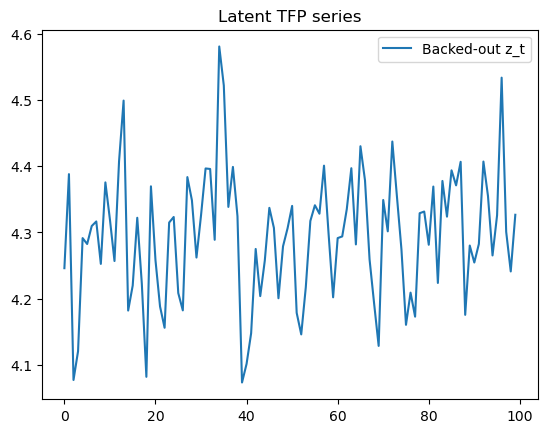

In [11]:
z = back_out_z(0.888, w, k)
plt.plot(z, label='Backed-out z_t')
plt.title('Latent TFP series')
plt.legend()

In [12]:
mu_hat

np.float64(1.1017571251634133)

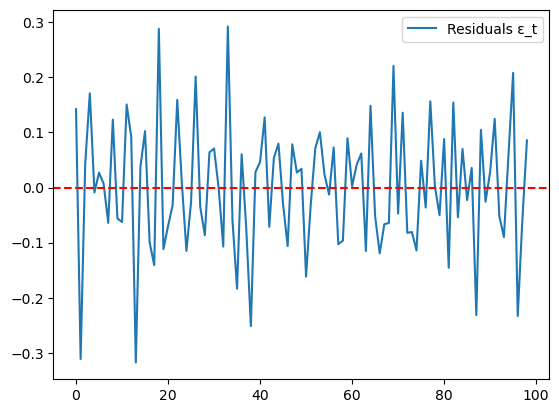

In [13]:
z_prev = np.concatenate([[mu_hat], z[:-1]])   # include z_0 = μ
eps = z[1:] - rho_hat * z_prev[1:] - (1 - rho_hat) * mu_hat

# Should be white noise around zero
plt.plot(eps, label='Residuals ε_t')
plt.axhline(0, color='r', linestyle='--')
plt.legend()

Text(0.5, 1.0, 'Q-Q plot of residuals')

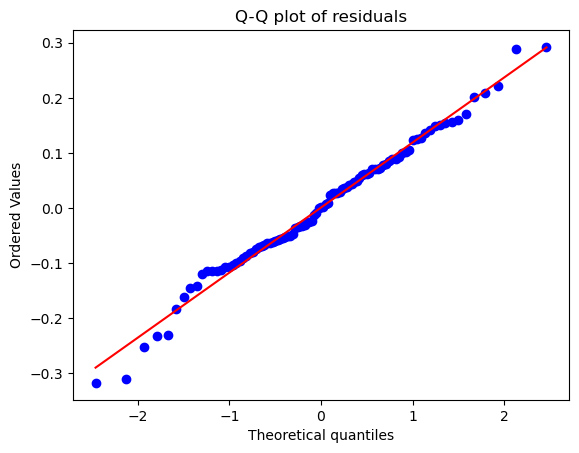

In [14]:
from scipy.stats import probplot
probplot(eps, dist="norm", plot=plt)
plt.title('Q-Q plot of residuals')


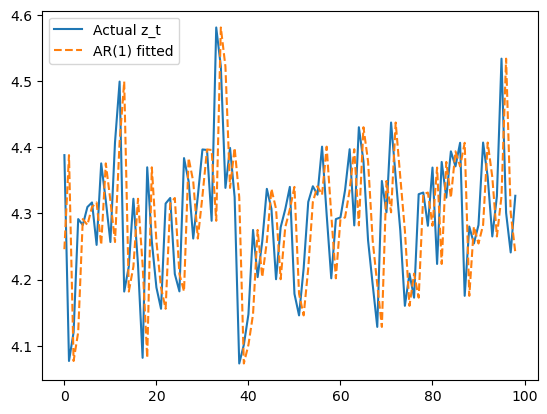

In [15]:
# Fitted values of z_t
z_fitted = rho_hat * z_prev + (1 - rho_hat) * mu_hat 

plt.plot(z[1:], label='Actual z_t')
plt.plot(z_fitted[1:], label='AR(1) fitted', linestyle='--')
plt.legend()

In [17]:
p = np.array([0.4, 0.8, 1.0, 0.2])
n = len(w) - 1

v1 = n_log_likelihood(p, w, k)
v2 = log_likelihood(p, w, k)

print(v1, v2)
print("Difference:", v2 - v1)
print("Expected:", 0.5 * n * np.log(2 * np.pi))

4164.657638927057 4255.632553714324
Difference: 90.97491478726715
Expected: 90.97491478726259


In [19]:
alpha, rho, mu, sigma = result.x
z = back_out_z(alpha, w, k)

eps = z[1:] - rho*z[:-1] - (1-rho)*mu
u = eps / sigma

print("Residual mean:", u.mean())
print("Residual SD:", u.std(ddof=0))
print("Sigma check:", np.sqrt(np.mean(eps**2)), sigma)

Residual mean: 0.019926876843376223
Residual SD: 0.9998014999059651
Sigma check: 0.09731268064166072 0.09731267482066247


Residual mean: 0.019926876843376223
Residual SD: 0.9998014999059651
Sigma check: 0.09731268064166072 0.09731267482066247


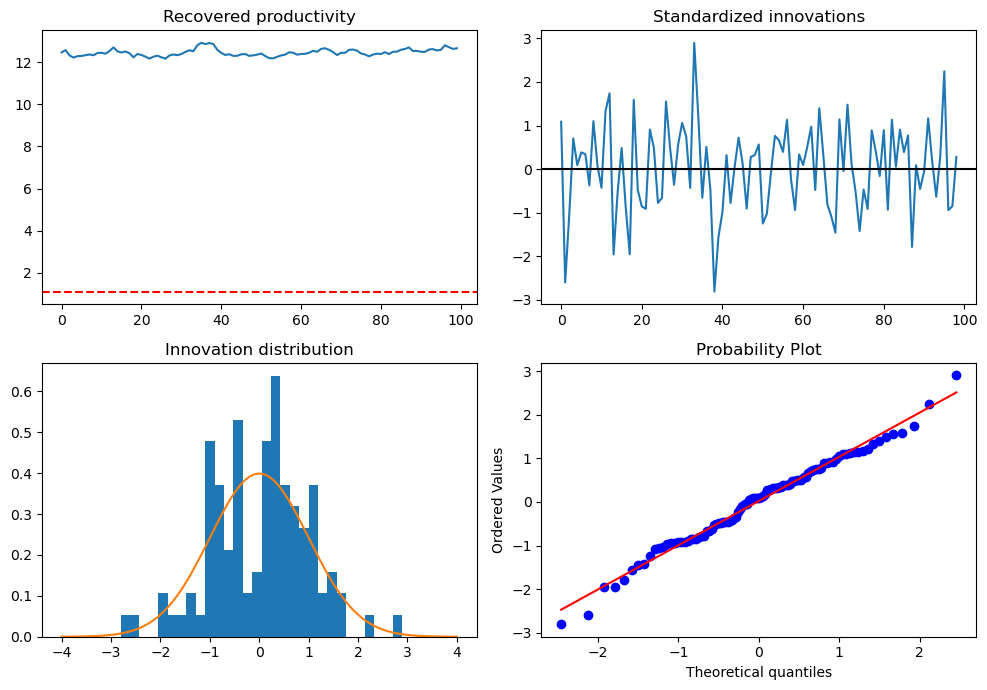

In [21]:
alpha, rho, mu, sigma = result.x
z = back_out_z(alpha, w, k)

eps = z[1:] - rho*z[:-1] - (1-rho)*mu
u = eps / sigma

print("Residual mean:", u.mean())
print("Residual SD:", u.std(ddof=0))
print("Sigma check:", np.sqrt(np.mean(eps**2)), sigma)

import matplotlib.pyplot as plt
from scipy.stats import probplot

fig, ax = plt.subplots(2, 2, figsize=(10, 7))

ax[0, 0].plot(z)
ax[0, 0].axhline(mu, color="red", linestyle="--")
ax[0, 0].set_title("Recovered productivity")

ax[0, 1].plot(u)
ax[0, 1].axhline(0, color="black")
ax[0, 1].set_title("Standardized innovations")

ax[1, 0].hist(u, bins=30, density=True)
x = np.linspace(-4, 4, 200)
ax[1, 0].plot(x, norm.pdf(x))
ax[1, 0].set_title("Innovation distribution")

probplot(u, dist="norm", plot=ax[1, 1])
plt.tight_layout()

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd

β = 0.99

# 1. Get z
def back_out_z(alpha, w, k):
    w = np.asarray(w, dtype=float)
    k = np.asarray(k, dtype=float)
    return np.log(w / ((1 - alpha) * k**alpha))

## 1. Get z
#def back_out_z(α, w, k):
#
#    """Back out the z_t series given α and data (w_t, k_t)."""
#    z = np.log(w / ((1 - α) * k**α))
#    
#    return z
#
# Now we try to get the loglikelihood through z
# 2. LOG-LIKELIHOOD
#    From eq (5): z_t = ρ*z_{t-1} + (1-ρ)*μ + ε_t
#    => ε_t = z_t - ρ*z_{t-1} - (1-ρ)*μ  ~  N(0, σ²)
#
#    Assumption: z_0 = 0, so z_1 is the following process z_t = ρ*z_{t-1} + (1-ρ)*μ +ϵ_t
#    We condition on z_1, so the likelihood runs from t=2,...,T.

def n_log_likelihood(params, wt, kt):
    α, ρ, μ, σ = params
    z = back_out_z(α, wt, kt)   # ← pass wt, kt, not globals w, k
    z_curr = z[1:]
    z_prev = z[:-1]
    ε = z_curr - ρ * z_prev - (1 - ρ) * μ
    n = len(ε)
    nll = n * np.log(σ) + 0.5 * np.sum(ε**2) / (σ**2)
    return nll

# ─────────────────────────────────────────
# 3. OPTIMIZATION
# ─────────────────────────────────────────
# Initial guess for (α, ρ, μ, σ)
params0 =  [0.80, 0.90, 1.0, 0.50]

result = minimize(
    n_log_likelihood,
    params0,
    args=(w, k),
    method="L-BFGS-B",          # gradient-based, handles box constraints
    bounds=[
        (1e-6, 1 - 1e-6),
        (-1 + 1e-6, 1 - 1e-6),
        (None, None),       # mu unrestricted
        (1e-6, None),
    ],
    
    options={"ftol": 1e-12, "gtol": 1e-8, "maxiter": 10_000}
)

# ─────────────────────────────────────────
# 4. RESULTS & VARIANCE-COVARIANCE MATRIX
# ─────────────────────────────────────────
alpha_hat, rho_hat, mu_hat, sigma_hat = result.x
print("=== MLE Estimates (Part a) ===")
print(f"  α̂  = {alpha_hat:.6f}")
print(f"  ρ̂  = {rho_hat:.6f}")
print(f"  μ̂  = {mu_hat:.6f}")
print(f"  σ̂  = {sigma_hat:.6f}")

=== MLE Estimates (Part a) ===
  α̂  = 0.462577
  ρ̂  = 0.716876
  μ̂  = 9.453289
  σ̂  = 0.092454


In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd

β = 0.99

# 1. Get z
def back_out_z_r(alpha, r, k):
    r = np.asarray(r, dtype=float)
    k = np.asarray(k, dtype=float)
    return np.log(r / (alpha * k**(alpha-1)))

## 1. Get z
#def back_out_z(α, w, k):
#
#    """Back out the z_t series given α and data (w_t, k_t)."""
#    z = np.log(w / ((1 - α) * k**α))
#    
#    return z
#
# Now we try to get the loglikelihood through z
# 2. LOG-LIKELIHOOD
#    From eq (5): z_t = ρ*z_{t-1} + (1-ρ)*μ + ε_t
#    => ε_t = z_t - ρ*z_{t-1} - (1-ρ)*μ  ~  N(0, σ²)
#
#    Assumption: z_0 = 0, so z_1 is the following process z_t = ρ*z_{t-1} + (1-ρ)*μ +ϵ_t
#    We condition on z_1, so the likelihood runs from t=2,...,T.

def n_log_likelihood_r(params, r, k):
    α, ρ, μ, σ = params
    z = back_out_z_r(α, r, k)  
    z_curr = z[1:]
    z_prev = z[:-1]
    ε = z_curr - ρ * z_prev - (1 - ρ) * μ
    n = len(ε)
    nll = n * np.log(σ) + 0.5 * np.sum(ε**2) / (σ**2)
    return nll

# ─────────────────────────────────────────
# 3. OPTIMIZATION
# ─────────────────────────────────────────
# Initial guess for (α, ρ, μ, σ)
params0 =  [0.70, 0.50, 4.0, 0.10]

result = minimize(
    n_log_likelihood_r,
    params0,
    args=(r, k),
    method="L-BFGS-B",
        bounds=[
        (1e-6, 1 - 1e-6),
        (-1 + 1e-6, 1 - 1e-6),
        (None, None),       # mu unrestricted
        (1e-6, None),
    ],
    options={"ftol": 1e-12, "gtol": 1e-8, "maxiter": 10_000}
)

# ─────────────────────────────────────────
# 4. RESULTS & VARIANCE-COVARIANCE MATRIX
# ─────────────────────────────────────────
alpha_hat, rho_hat, mu_hat, sigma_hat = result.x
print("=== MLE Estimates (Part a) ===")
print(f"  α̂  = {alpha_hat:.6f}")
print(f"  ρ̂  = {rho_hat:.6f}")
print(f"  μ̂  = {mu_hat:.6f}")
print(f"  σ̂  = {sigma_hat:.6f}")

=== MLE Estimates (Part a) ===
  α̂  = 0.251070
  ρ̂  = 0.999999
  μ̂  = 2.317661
  σ̂  = 0.097313


Mean implied alpha: 0.4199999999999999
SD implied alpha: 1.516176105081664e-16
Min/max: 0.4199999999999996 0.4199999999999999


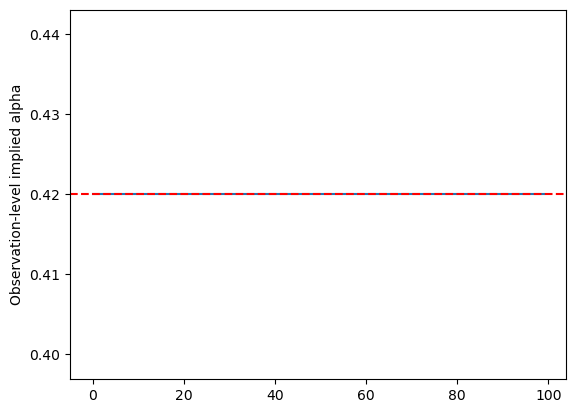

In [47]:
w_arr = np.asarray(w, dtype=float)
r_arr = np.asarray(r, dtype=float)
k_arr = np.asarray(k, dtype=float)

alpha_t = r_arr * k_arr / (w_arr + r_arr * k_arr)

print("Mean implied alpha:", alpha_t.mean())
print("SD implied alpha:", alpha_t.std())
print("Min/max:", alpha_t.min(), alpha_t.max())

plt.plot(alpha_t)
plt.axhline(alpha_t.mean(), color="red", linestyle="--")
plt.ylabel("Observation-level implied alpha")
plt.show()

In [49]:
r_arr * k_arr / (w_arr + r_arr * k_arr)

array([0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42, 0.42,
       0.42])

In [50]:
r * k / (w + r * k)

0     0.42
1     0.42
2     0.42
3     0.42
4     0.42
      ... 
95    0.42
96    0.42
97    0.42
98    0.42
99    0.42
Length: 100, dtype: float64

In [53]:
alpha = 0.42

z_w = back_out_z(alpha, w_arr, k_arr)
z_r = back_out_z_r(alpha, r_arr, k_arr)

difference = z_r - z_w

print("Mean difference:", difference.mean())
print("SD difference:", difference.std())

Mean difference: 0.0
SD difference: 0.0


In [52]:
difference

array([-0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32277339,
       -0.32277339, -0.32277339, -0.32277339, -0.32277339, -0.32

In [63]:
bounds=[
    (1e-6, 1 - 1e-6),
    (-1 + 1e-6, 1 - 1e-6),
    (None, None),       # mu unrestricted
    (1e-6, None),
]

In [64]:
result_w = minimize(
    n_log_likelihood,
    params0,
    args=(w, k),
    method="L-BFGS-B",
    bounds=bounds,
)

result_r = minimize(
    n_log_likelihood_r,
    params0,
    args=(r, k),
    method="L-BFGS-B",
    bounds=bounds,
)

print("Wage:", result_w.x, result_w.fun, result_w.success)
print("Rental:", result_r.x, result_r.fun, result_r.success)

Wage: [0.25106879 0.999999   1.10175723 0.09731267] -181.15277133540124 True
Rental: [0.71670455 0.46279046 4.82354015 0.09245462] -186.2238543074211 True


In [65]:
w_arr = np.asarray(w, float)
r_arr = np.asarray(r, float)
k_arr = np.asarray(k, float)

log_ratio = np.mean(np.log(r_arr * k_arr / w_arr))

alpha_r, rho_r, mu_r, sigma_r = result_r.x

C = log_ratio + np.log((1 - alpha_r) / alpha_r)

# Since z_r = z_w + C:
mu_w_equiv = mu_r - C

params_w_equiv = [alpha_r, rho_r, mu_w_equiv, sigma_r]

print("Rental NLL:", n_log_likelihood_r(result_r.x, r_arr, k_arr))
print("Equivalent wage NLL:",
      n_log_likelihood(params_w_equiv, w_arr, k_arr))
print("Equivalent wage parameters:", params_w_equiv)

Rental NLL: -186.2238543074211
Equivalent wage NLL: -186.2238543074211
Equivalent wage parameters: [np.float64(0.7167045462852802), np.float64(0.4627904587338992), np.float64(6.074486864814829), np.float64(0.09245462013535838)]


In [85]:
result_w2 = minimize(
    nll_w,
     [0.70, 0.50, 4.0, 0.10],
    args=(w_arr, k_arr),
    method="L-BFGS-B",
    bounds=[
        (1e-6, 1 - 1e-6),
        (-1 + 1e-6, 1 - 1e-6),
        (None, None),
        (1e-6, None),
    ],
    options={"ftol": 1e-12, "gtol": 1e-8, "maxiter": 10_000}
)

print(result_w2.x)
print(result_w2.fun)
print(result_w2.message)

[0.71677234 0.46270804 6.0736527  0.09245355]
-186.22385454369015
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [87]:
import numpy as np
from scipy.optimize import minimize

w = np.asarray(w, dtype=float)
r = np.asarray(r, dtype=float)
k = np.asarray(k, dtype=float)

def z_from_w(alpha, w, k):
    return np.log(w / ((1 - alpha) * k**alpha))

def z_from_r(alpha, r, k):
    return np.log(r / (alpha * k**(alpha - 1)))

def nll_w(params, w, k):
    alpha, rho, mu, sigma = params
    z = z_from_w(alpha, w, k)
    eps = z[1:] - rho*z[:-1] - (1-rho)*mu

    return len(eps)*np.log(sigma) + np.sum(eps**2)/(2*sigma**2)

def nll_r(params, r, k):
    alpha, rho, mu, sigma = params
    z = z_from_r(alpha, r, k)
    eps = z[1:] - rho*z[:-1] - (1-rho)*mu

    return len(eps)*np.log(sigma) + np.sum(eps**2)/(2*sigma**2)

bounds = [
    (1e-6, 1 - 1e-6),         # alpha
    (-1 + 1e-6, 1 - 1e-6),    # rho
    (None, None),              # mu unrestricted
    (1e-6, None),              # sigma
]

starts = [
    [0.20, 0.20, 0.0, 0.20],
    [0.42, 0.50, 1.0, 0.20],
    [0.50, 0.80, 2.0, 0.10],
    [0.70, 0.50, 4.0, 0.10],
    [0.80, 0.90, 1.0, 0.50],
    [0, 0, 0, 0]
]

def estimate_best(objective, data, k):
    results = []

    for start in starts:
        print(start)
        result = minimize(
            objective,
            start,
            args=(data, k),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "ftol": 1e-12,
                "gtol": 1e-8,
                "maxiter": 10_000,
            },
        )
        if result.success and np.isfinite(result.fun):
            results.append(result)

    return min(results, key=lambda result: result.fun)

result_w = estimate_best(nll_w, w, k)
result_r = estimate_best(nll_r, r, k)

print("Wage:")
print(result_w.x, result_w.fun)

print("Rental rate:")
print(result_r.x, result_r.fun)

[0.2, 0.2, 0.0, 0.2]
[0.42, 0.5, 1.0, 0.2]
[0.5, 0.8, 2.0, 0.1]
[0.7, 0.5, 4.0, 0.1]
[0.8, 0.9, 1.0, 0.5]
[0, 0, 0, 0]
[0.2, 0.2, 0.0, 0.2]
[0.42, 0.5, 1.0, 0.2]
[0.5, 0.8, 2.0, 0.1]
[0.7, 0.5, 4.0, 0.1]
[0.8, 0.9, 1.0, 0.5]
[0, 0, 0, 0]
Wage:
[0.46257703 0.71687635 9.45328913 0.09245373] -186.22385462280974
Rental rate:
[0.46254387 0.71690002 9.28108408 0.09245363] -186.2238545917797


In [128]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd

β = 0.99

# 1. Get z
def back_out_z(alpha, w, k):
    w = np.asarray(w, dtype=float)
    k = np.asarray(k, dtype=float)
    return np.log(w / ((1 - alpha) * k**alpha))

## 1. Get z
#def back_out_z(α, w, k):
#
#    """Back out the z_t series given α and data (w_t, k_t)."""
#    z = np.log(w / ((1 - α) * k**α))
#    
#    return z
#
# Now we try to get the loglikelihood through z
# 2. LOG-LIKELIHOOD
#    From eq (5): z_t = ρ*z_{t-1} + (1-ρ)*μ + ε_t
#    => ε_t = z_t - ρ*z_{t-1} - (1-ρ)*μ  ~  N(0, σ²)
#
#    Assumption: z_0 = 0, so z_1 is the following process z_t = ρ*z_{t-1} + (1-ρ)*μ +ϵ_t
#    We condition on z_1, so the likelihood runs from t=2,...,T.

def n_log_likelihood(params, wt, kt):
    α, ρ, μ, σ = params
    z = back_out_z(α, wt, kt)   # ← pass wt, kt, not globals w, k
    z_curr = z[1:]
    z_prev = z[:-1]
    ε = z_curr - ρ * z_prev - (1 - ρ) * μ
    n = len(ε)
    nll = n * np.log(σ) + 0.5 * np.sum(ε**2) / (σ**2)
    return nll

# ─────────────────────────────────────────
# 3. OPTIMIZATION
# ─────────────────────────────────────────
# Initial guess for (α, ρ, μ, σ)
params0 = [0.1, 0.1, 20, 1.2]
params0 = [0.5, 0.5, 12.0, 0.5]

result = minimize(
    n_log_likelihood,
    params0,
    args=(w, k),
    method="L-BFGS-B",          # gradient-based, handles box constraints
    bounds=[(1e-6, 1-1e-6),     # α ∈ (0,1)
            (-1+1e-6, 1-1e-6),  # ρ ∈ (-1,1)
            (1e-6, None),        # μ > 0
            (1e-6, None)],       # σ > 0
    options={"ftol": 1e-25, "gtol": 1e-20, "maxiter": 10_000}
)

# ─────────────────────────────────────────
# 4. RESULTS & VARIANCE-COVARIANCE MATRIX
# ─────────────────────────────────────────
alpha_hat, rho_hat, mu_hat, sigma_hat = result.x
print("=== MLE Estimates (Part a) ===")
print(f"  α̂  = {alpha_hat:.6f}")
print(f"  ρ̂  = {rho_hat:.6f}")
print(f"  μ̂  = {mu_hat:.6f}")
print(f"  σ̂  = {sigma_hat:.6f}")

=== MLE Estimates (Part a) ===
  α̂  = 0.462567
  ρ̂  = 0.716887
  μ̂  = 9.453428
  σ̂  = 0.092454


In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pandas as pd

β = 0.99

# 1. Get z
def back_out_z_r(alpha, r, k):
    r = np.asarray(r, dtype=float)
    k = np.asarray(k, dtype=float)
    return np.log(r / (alpha * k**(alpha-1)))

## 1. Get z
#def back_out_z(α, w, k):
#
#    """Back out the z_t series given α and data (w_t, k_t)."""
#    z = np.log(w / ((1 - α) * k**α))
#    
#    return z
#
# Now we try to get the loglikelihood through z
# 2. LOG-LIKELIHOOD
#    From eq (5): z_t = ρ*z_{t-1} + (1-ρ)*μ + ε_t
#    => ε_t = z_t - ρ*z_{t-1} - (1-ρ)*μ  ~  N(0, σ²)
#
#    Assumption: z_0 = 0, so z_1 is the following process z_t = ρ*z_{t-1} + (1-ρ)*μ +ϵ_t
#    We condition on z_1, so the likelihood runs from t=2,...,T.

def n_log_likelihood_r(params, r, k):
    α, ρ, μ, σ = params
    z = back_out_z_r(α, r, k)  
    z_curr = z[1:]
    z_prev = z[:-1]
    ε = z_curr - ρ * z_prev - (1 - ρ) * μ
    n = len(ε)
    nll = n * np.log(σ) + 0.5 * np.sum(ε**2) / (σ**2)
    return nll

# ─────────────────────────────────────────
# 3. OPTIMIZATION
# ─────────────────────────────────────────
# Initial guess for (α, ρ, μ, σ)
params0 =  [0.8, 0.9, 1.0, 0.5]

result = minimize(
    n_log_likelihood_r,
    params0,
    args=(r, k),
    method="L-BFGS-B",
        bounds=[
        (1e-6, 1 - 1e-6),
        (-1 + 1e-6, 1 - 1e-6),
        (None, None),       # mu unrestricted
        (1e-6, None),
    ],
    options={"ftol": 1e-25, "gtol": 1e-20, "maxiter": 10_000}
)

# ─────────────────────────────────────────
# 4. RESULTS & VARIANCE-COVARIANCE MATRIX
# ─────────────────────────────────────────
alpha_hat_r, rho_hat, mu_hat, sigma_hat = result.x
print("=== MLE Estimates (Part a) ===")
print(f"  α̂  = {alpha_hat:.6f}")
print(f"  ρ̂  = {rho_hat:.6f}")
print(f"  μ̂  = {mu_hat:.6f}")
print(f"  σ̂  = {sigma_hat:.6f}")

=== MLE Estimates (Part a) ===
  α̂  = 0.462567
  ρ̂  = 0.716900
  μ̂  = 9.281084
  σ̂  = 0.092454


In [133]:
alpha_hat_r - alpha_hat

np.float64(-2.326854341855311e-05)

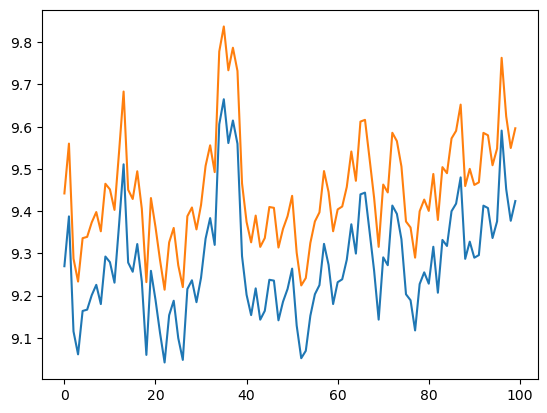

In [132]:
plt.plot(back_out_z_r(alpha_hat, r,k))
plt.plot(back_out_z(alpha_hat, w,k))

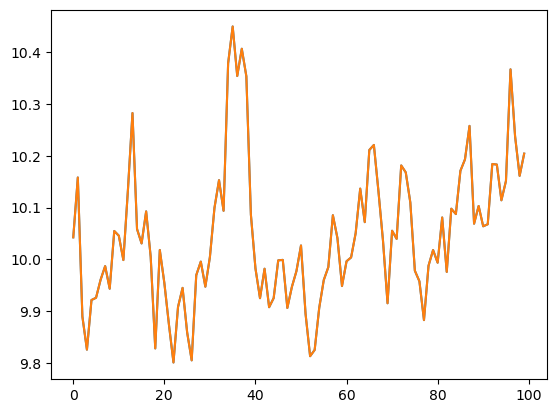

In [134]:
plt.plot(back_out_z_r(0.42, r,k))
plt.plot(back_out_z(0.42, w,k))